# Problem 3.1: Bayesian Linear Regression 
Implement Bayesian linear regression using PyMC:
- Use a polynomial regression problem with noisy data (use synthetic data
or Advertising Dataset from Kaggle).
- Set appropriate priors for coefficients and noise.
- Sample from the posterior using MCMC.
- Visualize posterior distributions and credible intervals.
- Compare with standard maximum likelihood estimation.# Problem 3.1

In [1]:
import numpy as np
import random
import os 
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, RationalQuadratic, ExpSineSquared
from sklearn.metrics import mean_absolute_error


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
c:\Users\oliwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
def set_global_seed(seed=42):
    """Sets a global seed for full reproducibility."""
    # Seed for Python's built-in random module
    random.seed(seed)
    
    # Seed for NumPy (used internally by Pandas and Scikit-Learn)
    np.random.seed(seed)
    
    # Prevent random dictionary hashing behavior in Python
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    print(f"Global random seed set to: {seed}")

# Run the function at the start
set_global_seed(42)

Global random seed set to: 42


#### **1. Synthetic Data Generation**
We simulate 60 data points based on the underlying quadratic relationship:
$$Y_i \sim N(\mu_i, \sigma)$$
$$\mu_i = \beta_0 + \beta_1x_i + \beta_2x_i^2$$

Random Gaussian noise is added to the true curve to simulate real-world variance and give our Bayesian model a proper challenge.

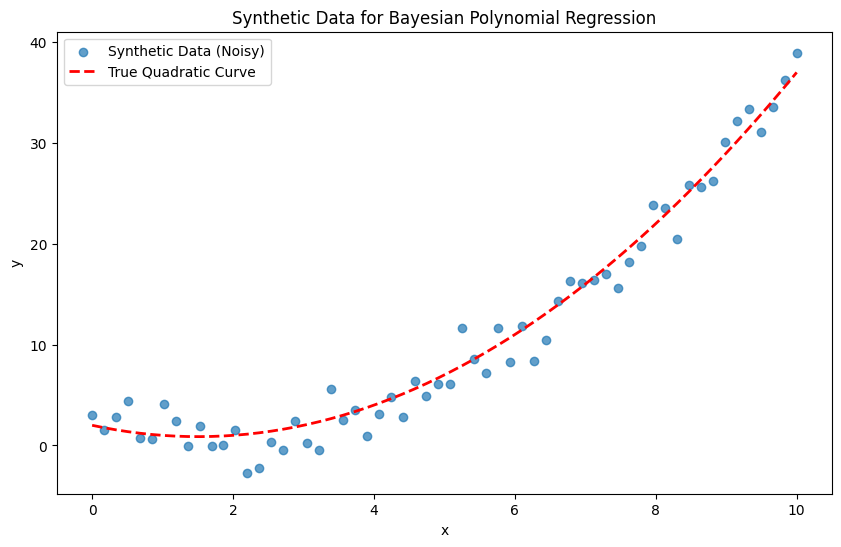

In [3]:
# 1. Generate synthetic data (60 points)
np.random.seed(42)
n_points = 60
x = np.linspace(0, 10, n_points)

# True parameters
beta0_true = 2.0
beta1_true = -1.5
beta2_true = 0.5
sigma_true = 2.0

# Quadratic model: y = b0 + b1*x + b2*x^2 + noise
y_true = beta0_true + beta1_true * x + beta2_true * x**2
y_noisy = y_true + np.random.normal(0, sigma_true, size=n_points)

# Plot the generated data
plt.figure(figsize=(10, 6))
plt.scatter(x, y_noisy, label='Synthetic Data (Noisy)', alpha=0.7)
plt.plot(x, y_true, 'r--', label='True Quadratic Curve', linewidth=2)
plt.title("Synthetic Data for Bayesian Polynomial Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend();

#### **2. Model Definition and MCMC Sampling**

In this step, we construct the Bayesian model using the `PyMC` library.
* **Priors:** We assign weakly informative Normal distributions to the polynomial coefficients ($\beta_0, \beta_1, \beta_2$) and a Half-Normal distribution to the noise standard deviation ($\sigma$).
* **Likelihood:** The observed data is modeled as a Normal distribution centered around our quadratic expected value equation ($\mu$).
* **Sampling:** We use Markov Chain Monte Carlo (MCMC) with 4 independent chains to draw samples from the posterior distribution.

In [4]:
print("Building model and starting MCMC sampling...")

with pm.Model() as bayesian_poly_model:
    # 1. Priors for parameters (weakly informative)
    beta0 = pm.Normal('beta0', mu=0, sigma=10)
    beta1 = pm.Normal('beta1', mu=0, sigma=10)
    beta2 = pm.Normal('beta2', mu=0, sigma=10)
    sigma = pm.HalfNormal('sigma', sigma=10)
    
    # 2. Expected value (the quadratic function)
    mu = beta0 + beta1 * x + beta2 * (x ** 2)
    
    # 3. Likelihood of observations
    Y_obs = pm.Normal('Y_obs', mu=mu, sigma=sigma, observed=y_noisy)
    
    # 4. Sample from the posterior distribution
    # Using 4 chains as requested in the assignment
    trace = pm.sample(draws=2000, tune=1000, chains=4, return_inferencedata=True, random_seed=42)
    
print("MCMC sampling completed successfully!")

Building model and starting MCMC sampling...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta1, beta2, sigma]


c:\Users\oliwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 193 seconds.


MCMC sampling completed successfully!


#### **3. Posterior Distributions and Credible Intervals**

With the MCMC sampling complete, we now analyze the posterior distributions of our parameters. We use the `ArviZ` library to visualize:
1.  **Trace Plots:** To verify that our 4 independent MCMC chains converged successfully and mixed well.
2.  **Posterior Densities:** To display the most probable values for each parameter, explicitly highlighting the **94% Highest Density Interval (HDI)**, which represents the credible range containing 94% of the marginal probability.

Generating trace plots...


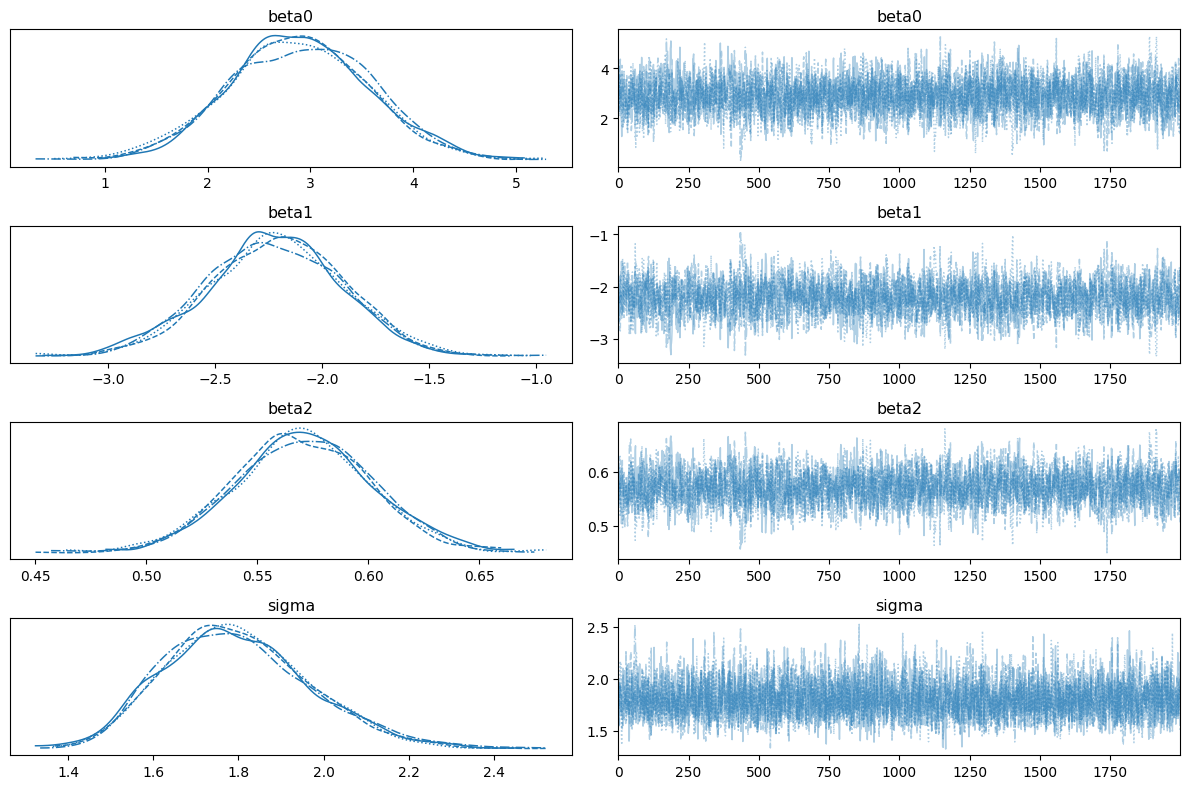

Generating posterior density plots (94% HDI)...


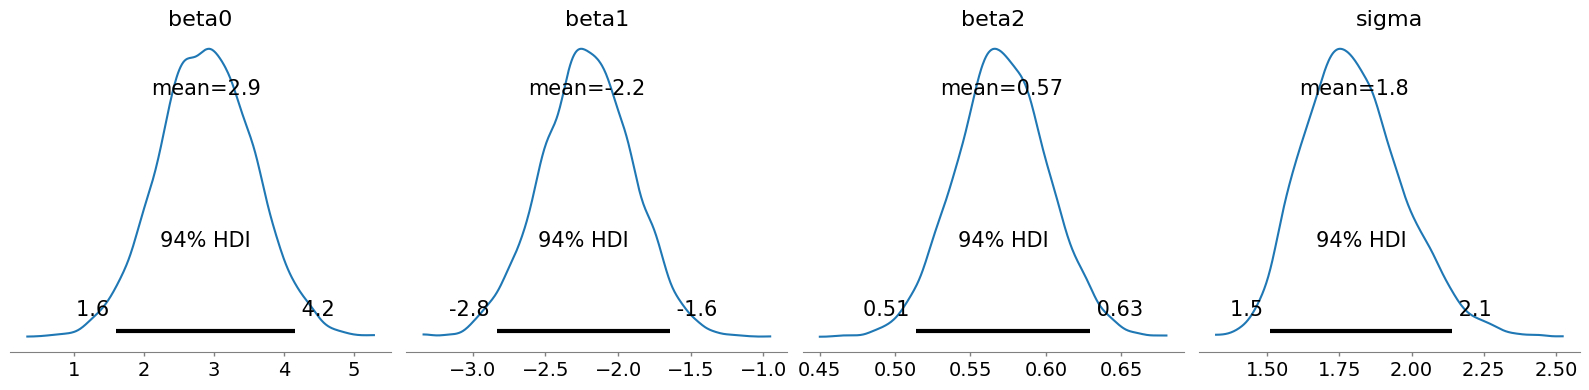

In [5]:
# 5. Plot the MCMC trace (checks if chains converged and mixed well)
print("Generating trace plots...")
az.plot_trace(trace, figsize=(12, 8))
plt.tight_layout()
plt.show()

# 6. Plot posterior densities with 94% Credible Intervals (HDI)
print("Generating posterior density plots (94% HDI)...")
az.plot_posterior(trace, hdi_prob=0.94, figsize=(16, 4))
plt.tight_layout()
plt.show()

The diagnostic trace plots confirm that the MCMC algorithm converged successfully, as evidenced by the dense, well-mixed chains. Furthermore, the posterior density distributions quantify our uncertainty by defining the 94% Highest Density Intervals (HDI) for each variable. Ultimately, the model accurately recovered the true generating parameters ($\beta_0, \beta_1, \beta_2, \sigma$) within these credible intervals, demonstrating the robustness of the Bayesian approach.

#### **4. Posterior Mean Curve and MLE Comparison**

Next, we calculate the **posterior mean curve** and its 94% credible interval. We will plot this against the true generated curve and a standard **Maximum Likelihood Estimation (MLE)** fit (using Ordinary Least Squares) to compare how the Bayesian approach handles the noisy data compared to traditional methods.

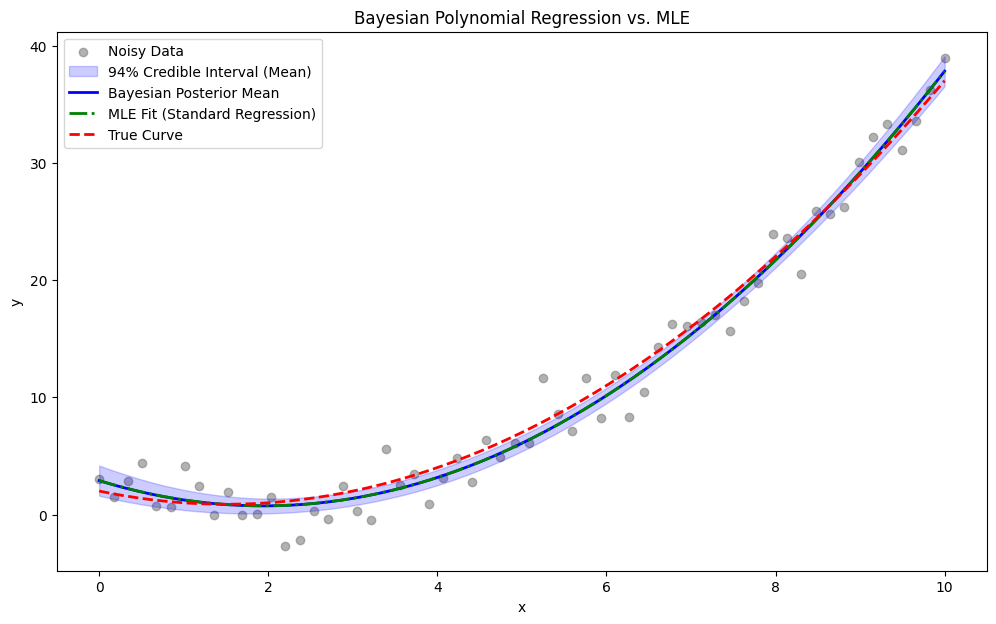

In [6]:
# Extract posterior samples for the parameters
beta0_samples = trace.posterior['beta0'].values.flatten()
beta1_samples = trace.posterior['beta1'].values.flatten()
beta2_samples = trace.posterior['beta2'].values.flatten()

# Create a dense grid of X values for a smooth curve
x_dense = np.linspace(0, 10, 200)

# 1. Calculate Bayesian Posterior Mean Curve and 94% Credible Interval
# Calculate mu for every sample across the dense X grid
mu_pred = beta0_samples[:, None] + beta1_samples[:, None] * x_dense + beta2_samples[:, None] * (x_dense**2)

# Mean curve
mu_mean = mu_pred.mean(axis=0)

# 94% Credible Interval for the mean (3rd and 97th percentiles)
mu_hdi_lower = np.percentile(mu_pred, 3, axis=0)
mu_hdi_upper = np.percentile(mu_pred, 97, axis=0)

# 2. Calculate Maximum Likelihood Estimation (MLE) using Ordinary Least Squares
# np.polyfit returns coefficients starting from the highest degree (beta2, beta1, beta0)
mle_coeffs = np.polyfit(x, y_noisy, 2)
y_mle = np.polyval(mle_coeffs, x_dense)

# True curve for comparison
y_true_dense = beta0_true + beta1_true * x_dense + beta2_true * (x_dense**2)

# 3. Plotting everything together
plt.figure(figsize=(12, 7))

# Plot original noisy data
plt.scatter(x, y_noisy, color='gray', alpha=0.6, label='Noisy Data')

# Plot 94% Credible Interval for the mean
plt.fill_between(x_dense, mu_hdi_lower, mu_hdi_upper, color='blue', alpha=0.2, label='94% Credible Interval (Mean)')

# Plot Bayesian Posterior Mean Curve
plt.plot(x_dense, mu_mean, color='blue', linewidth=2, label='Bayesian Posterior Mean')

# Plot MLE fit
plt.plot(x_dense, y_mle, color='green', linestyle='-.', linewidth=2, label='MLE Fit (Standard Regression)')

# Plot True Curve
plt.plot(x_dense, y_true_dense, color='red', linestyle='--', linewidth=2, label='True Curve')

plt.title("Bayesian Polynomial Regression vs. MLE")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

The plot demonstrates that both the **Bayesian Posterior Mean** (blue line) and the standard **MLE Fit** (green line) successfully approximate the **True Curve** (red dashed line). Because we used weakly informative priors, the Bayesian mean and MLE yield nearly identical point estimates. 

The significant advantage of the Bayesian approach is the **94% Credible Interval** (the blue shaded area). While standard regression only provides a single best-fit line, the Bayesian model quantifies our uncertainty, providing a range of plausible lines where the true mathematical average is highly likely to exist.

#### **5. Posterior Predictive Checks (94% Credible Intervals for $Y_i$)**

The previous credible interval represented the uncertainty of the mean curve ($\mu$). Now, we calculate the 94% credible intervals for the actual observations ($Y_i$). 

By using the `sample_posterior_predictive` method, the model incorporates both the uncertainty of the parameters and the estimated Gaussian noise ($\sigma$). The resulting wide predictive band illustrates where new data points are expected to fall, and we can visually verify that it successfully captures the vast majority of our original noisy data points.

Sampling: [Y_obs]


c:\Users\oliwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling posterior predictive distribution...


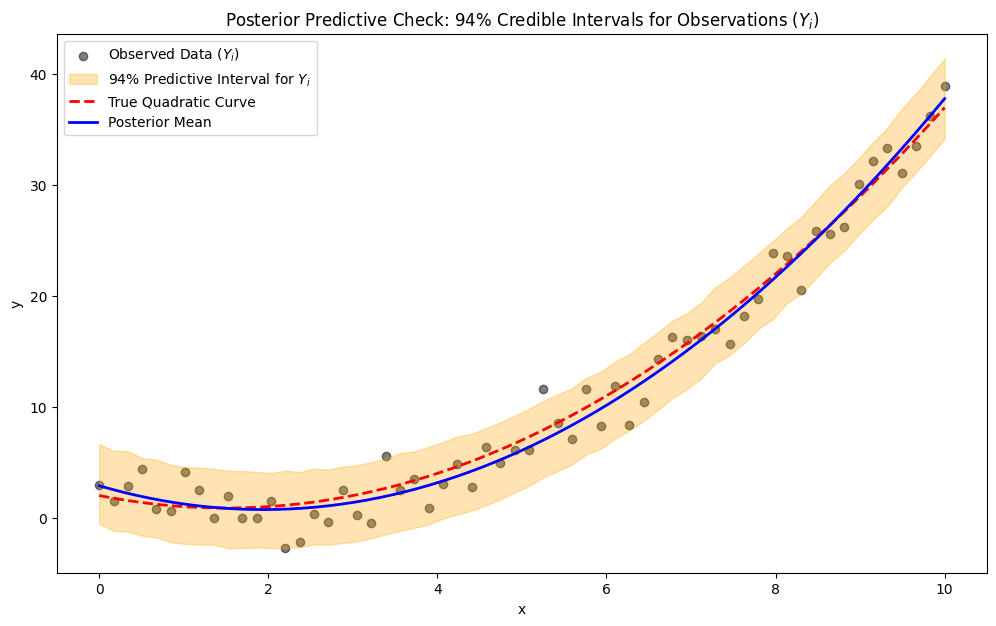

In [7]:
# 1. Generate posterior predictive samples
# This asks the model to generate new 'fake' data based on what it learned
print("Sampling posterior predictive distribution...")
with bayesian_poly_model:
    pm.sample_posterior_predictive(trace, extend_inferencedata=True, random_seed=42)

# 2. Calculate the 94% HDI for the predicted observations (Y_i)
# ArviZ automatically calculates the bounds across all chains and draws
y_pred_hdi = az.hdi(trace.posterior_predictive, hdi_prob=0.94)["Y_obs"]

# 3. Plotting the results
plt.figure(figsize=(12, 7))

# Plot the original noisy data points
plt.scatter(x, y_noisy, color='black', alpha=0.5, label='Observed Data ($Y_i$)')

# Plot the 94% Predictive Interval for Yi (The wide band)
plt.fill_between(x, y_pred_hdi[:, 0], y_pred_hdi[:, 1], color='orange', alpha=0.3, label='94% Predictive Interval for $Y_i$')

# Plot the True Curve for reference
plt.plot(x, y_true, color='red', linestyle='--', linewidth=2, label='True Quadratic Curve')

# Plot the Bayesian Posterior Mean (from previous step)
plt.plot(x_dense, mu_mean, color='blue', linewidth=2, label='Posterior Mean')

plt.title("Posterior Predictive Check: 94% Credible Intervals for Observations ($Y_i$)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

The final plot visualizes the **94% Predictive Interval** (the orange band) for individual observations ($Y_i$). 

* **Incorporating Noise:** Unlike the previous interval which only showed the uncertainty of the mean curve, this predictive band incorporates the estimated Gaussian noise ($\sigma$). It shows where the model expects actual new data points to fall.
* **Model Calibration:** The orange band successfully captures the vast majority of the observed noisy data points. The fact that a few points (roughly 6%) fall slightly outside or on the edge of the band is statistically expected for a 94% interval. 
* **Conclusion:** This confirms that the Bayesian model is well-calibrated. It successfully learned not only the underlying quadratic trend but also the true variance and noise of the environment.

# Problem 3.2: Gaussian Process Regression 
Apply Gaussian Processes to function approximation:
- Use GPyTorch or scikit-learn.
- Test on synthetic 1D and 2D functions.
- Use Mauna Loa CO2 dataset or temperature time series from your home town
- Experiment with different kernels (RBF, Matern, Periodic).
- Visualize mean predictions and uncertainty bounds.
- Discuss computational complexity for large datasets.


The task is divided into three main components:
1. **1D Synthetic Data:** Approximating a known mathematical function with added Gaussian noise, visualizing interpolation and extrapolation capabilities.
2. **2D Synthetic Data:** Extending the GP application to a two-dimensional surface.
3. **Mauna Loa CO2 Dataset:** Modeling real-world time series data by combining specific kernels (e.g., RBF and Periodic) to capture both long-term trends and seasonality, followed by an analysis of computational complexity.

## 1. 1D Synthetic Data

<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
C:\Users\oliwi\AppData\Local\Temp\ipykernel_28496\3493259182.py:32: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(X_grid, f(X_grid), 'r--', linewidth=2, label='True function $f(x) = x \sin(x)$')


Fitting GP...
Learned kernel: 5.55**2 * RBF(length_scale=1.62) + WhiteKernel(noise_level=0.637)


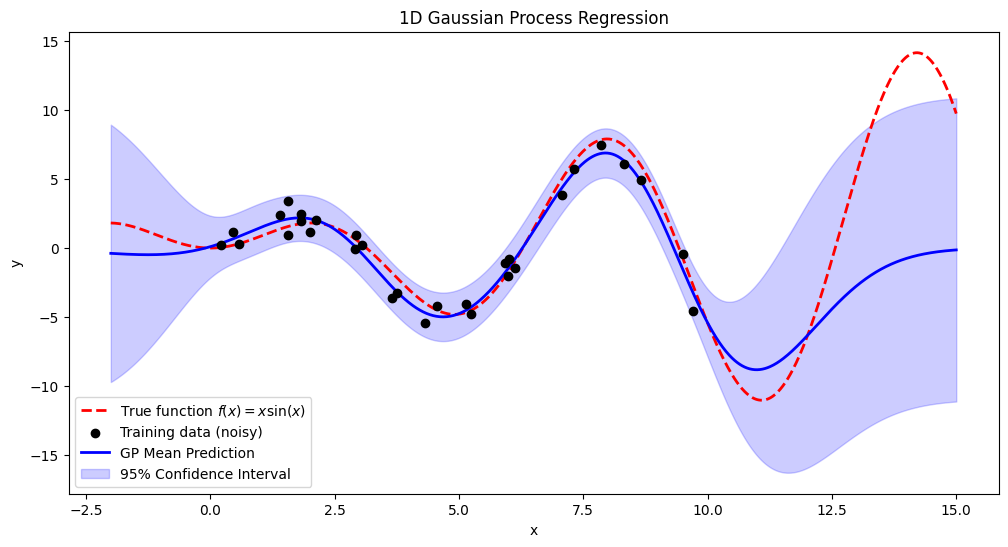

In [8]:
# 1. Assume some function f(x)
def f(x):
    return x * np.sin(x)

# 2. Generate synthetic data (30 points) with Gaussian noise
np.random.seed(42)
n_points = 30
# Training data between 0 and 10
X_train = np.random.uniform(0, 10, n_points).reshape(-1, 1)
y_true = f(X_train).ravel()
noise_std = 1.0
y_train = y_true + np.random.normal(0, noise_std, size=n_points)

# 3. Define the kernel
# ConstantKernel scales the RBF, WhiteKernel handles the Gaussian noise
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) \
         + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))

# 4. Fit Gaussian Process Regressor
print("Fitting GP...")
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gp.fit(X_train, y_train)
print(f"Learned kernel: {gp.kernel_}")

# 5. Predict on a dense, wide grid (covering training area + extrapolation)
# Grid from -2 to 15 (extrapolating outside the 0-10 training range)
X_grid = np.linspace(-2, 15, 1000).reshape(-1, 1)
y_mean, y_std = gp.predict(X_grid, return_std=True)

# 6. Visualize the results
plt.figure(figsize=(12, 6))
plt.plot(X_grid, f(X_grid), 'r--', linewidth=2, label='True function $f(x) = x \sin(x)$')
plt.scatter(X_train, y_train, c='black', label='Training data (noisy)', zorder=10)
plt.plot(X_grid, y_mean, 'b-', linewidth=2, label='GP Mean Prediction')

# Plot 95% Confidence Interval (1.96 * std)
plt.fill_between(X_grid.ravel(), 
                 y_mean - 1.96 * y_std, 
                 y_mean + 1.96 * y_std, 
                 alpha=0.2, color='blue', label='95% Confidence Interval')

plt.title('1D Gaussian Process Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.legend();

This plot perfectly illustrates the dual capability of a Gaussian Process: fitting data and quantifying uncertainty.

* **Interpolation (0 < x < 10):** Within the bounds of the training data, the GP successfully learns the underlying pattern of $f(x) = x \sin(x)$. The mean prediction (blue line) tracks the true function accurately, and the narrow 95% confidence interval indicates a high degree of certainty.
* **Extrapolation (x < 0 and x > 10):** In regions completely devoid of training data, the GP defaults to its prior assumptions. The mean prediction gracefully reverts to zero, and the confidence bounds expand dramatically. Instead of making unjustified, wild guesses (like polynomial regression often does), the GP honestly reflects its total uncertainty in unexplored areas.

## 2. 2D Synthetic Data

Fitting 2D GP...
Learned 2D kernel: 0.538**2 * RBF(length_scale=[0.986, 1.38]) + WhiteKernel(noise_level=0.0288)
Predicting surface...


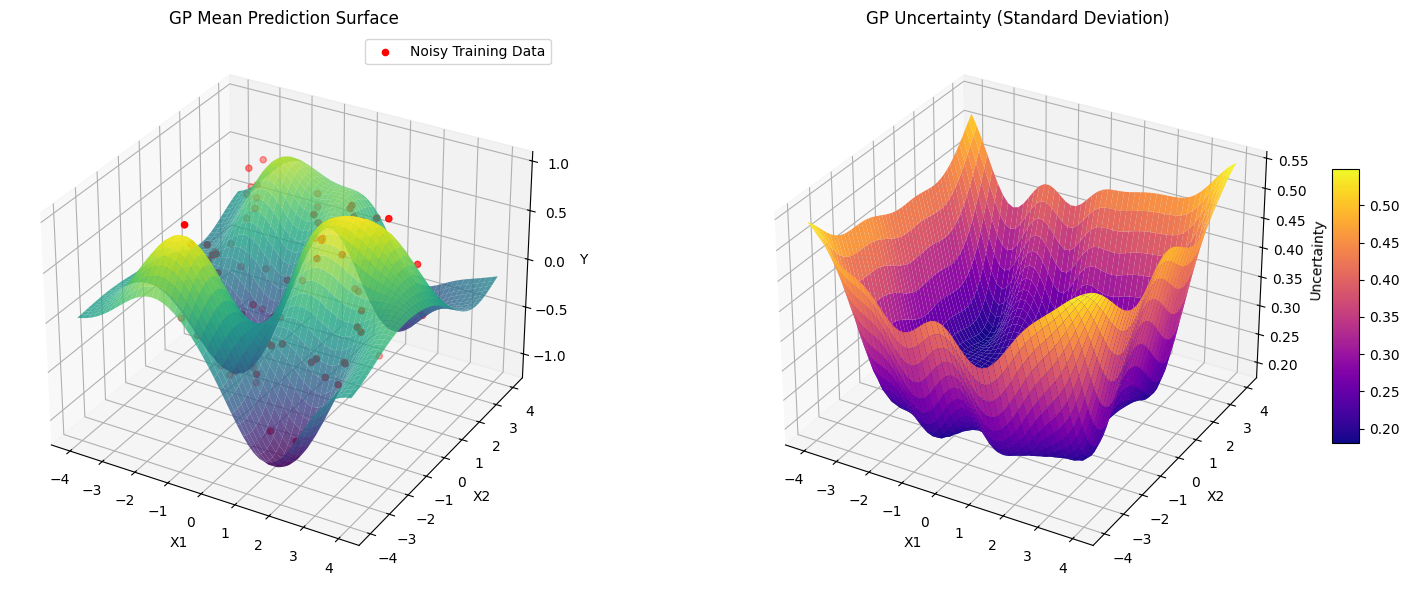

In [9]:
# 1. Define a 2D function
def f2d(X):
    # A simple wavy surface: sin(x1) * cos(x2)
    return np.sin(X[:, 0]) * np.cos(X[:, 1])

# 2. Generate 2D synthetic data
np.random.seed(42)
n_samples_2d = 100
# Points randomly scattered between -3 and 3
X_train_2d = np.random.uniform(-3, 3, (n_samples_2d, 2))
# Add some Gaussian noise
y_train_2d = f2d(X_train_2d) + np.random.normal(0, 0.2, n_samples_2d)

# 3. Define Kernel and fit the GP
print("Fitting 2D GP...")
# Using anisotropic RBF (different length scales for x1 and x2 if needed) + noise
kernel_2d = C(1.0) * RBF(length_scale=[1.0, 1.0]) + WhiteKernel(noise_level=0.1)
gp_2d = GaussianProcessRegressor(kernel=kernel_2d, n_restarts_optimizer=10, random_state=42)
gp_2d.fit(X_train_2d, y_train_2d)
print(f"Learned 2D kernel: {gp_2d.kernel_}")

# 4. Predict on a 2D grid
x1 = np.linspace(-4, 4, 50)
x2 = np.linspace(-4, 4, 50)
x1_mesh, x2_mesh = np.meshgrid(x1, x2)
# Flatten the grid to feed it to the model
X_grid_2d = np.c_[x1_mesh.ravel(), x2_mesh.ravel()]

print("Predicting surface...")
y_mean_2d, y_std_2d = gp_2d.predict(X_grid_2d, return_std=True)

# 5. Visualize the results using 3D plots
fig = plt.figure(figsize=(16, 6))

# Plot 1: Mean Prediction vs Training Data
ax1 = fig.add_subplot(121, projection='3d')
# Reshape predictions back to grid format
ax1.plot_surface(x1_mesh, x2_mesh, y_mean_2d.reshape(50, 50), cmap='viridis', alpha=0.8)
# Add original training points
ax1.scatter(X_train_2d[:, 0], X_train_2d[:, 1], y_train_2d, color='red', s=20, label='Noisy Training Data')
ax1.set_title('GP Mean Prediction Surface')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('Y')
ax1.legend()

# Plot 2: Uncertainty (Standard Deviation)
ax2 = fig.add_subplot(122, projection='3d')
surf = ax2.plot_surface(x1_mesh, x2_mesh, y_std_2d.reshape(50, 50), cmap='plasma')
ax2.set_title('GP Uncertainty (Standard Deviation)')
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.set_zlabel('Uncertainty')
fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()

These 3D plots successfully demonstrate how Gaussian Processes scale to multidimensional spaces. The left surface confirms that the model accurately reconstructed the underlying wavy function while effectively smoothing out the noise from the scattered training points. Crucially, the right plot visualizes spatial uncertainty: the dark "valleys" in the center indicate high confidence where data is dense, while the steep yellow "peaks" at the edges perfectly illustrate how uncertainty skyrockets during spatial extrapolation.

## 3. Mauna Loa CO2 Dataset

In [ ]:
# Loading the Mauna Loa CO2 data
df = pd.read_csv('problem2_data.csv') 

# Cleaning data: remove any negative values (indicating missing measurements for that month)
df = df[df['average'] > 0]

X = df['decimal date'].values.reshape(-1, 1)
y = df['average'].values

# Division into training set (1958-2015) and test set (>2015)
train_mask = X[:, 0] <= 2015.0
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[~train_mask], y[~train_mask]

# 3. Definition of Kernels
# Kernel 1: Longterm trend
k1 = 50.0**2 * RationalQuadratic(length_scale=50.0, alpha=50.0)

# Kernel 2: seasonality (Periodicity)
k2 = 2.0**2 * RBF(length_scale=100.0) * ExpSineSquared(length_scale=1.0, periodicity=1.0)

# Kernel 3: noise - CORRECTION: Changing np.inf to a very large, but finite number (e.g., 1e5)
k3 = WhiteKernel(noise_level=0.1**2, noise_level_bounds=(1e-5, 1e5))

kernel_complex = k1 + k2 + k3

# 4. Inicialization of the model and training
print("Training GP model on Mauna Loa data...")
gp_co2 = GaussianProcessRegressor(kernel=kernel_complex, alpha=0, normalize_y=True, n_restarts_optimizer=3)
gp_co2.fit(X_train, y_train)

print("\nTrained Kernel:\n", gp_co2.kernel_)

Training GP model on Mauna Loa data...


c:\Users\oliwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 56 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
c:\Users\oliwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 6 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)



Trained Kernel:
 35.7**2 * RationalQuadratic(alpha=40.9, length_scale=8.08) + 0.389**2 * RBF(length_scale=1.21e+03) * ExpSineSquared(length_scale=0.979, periodicity=2) + WhiteKernel(noise_level=0.000232)


Generating predictions for the year 2050...

--- Evaluation on Test Set ---
Mean Absolute Error (MAE): 29.90 ppm
Percentage of Test Points within 95% Confidence Interval: 100.00%


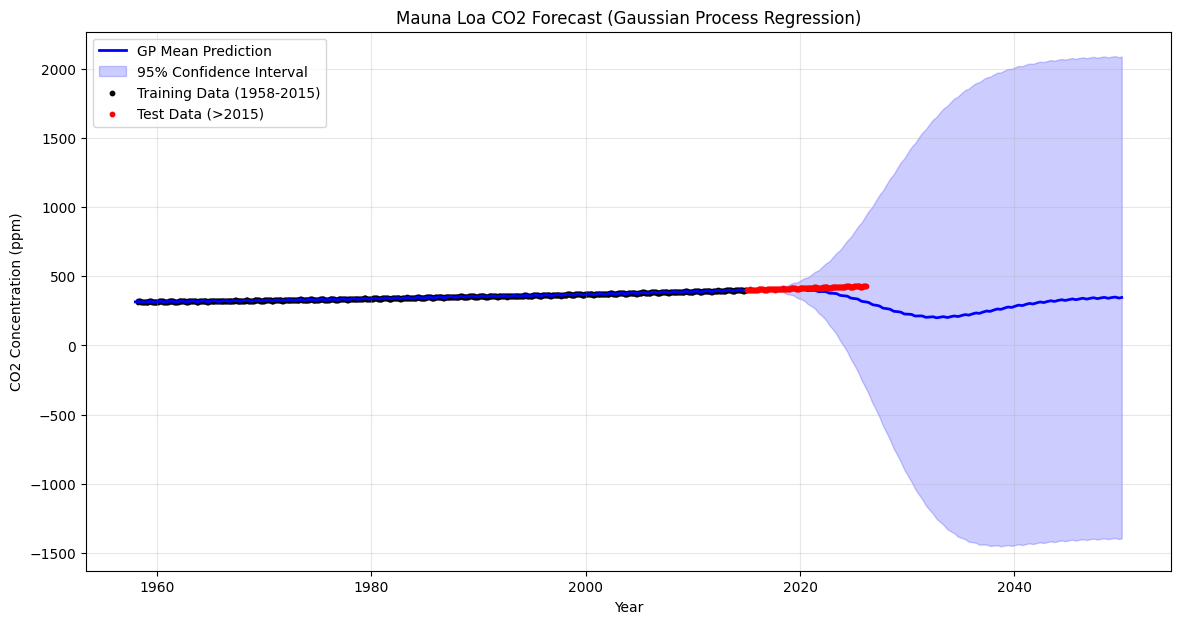

In [ ]:

print("Generating predictions for the year 2050...")
X_grid = np.linspace(1958, 2050, 1000).reshape(-1, 1)
y_mean, y_std = gp_co2.predict(X_grid, return_std=True)

y_pred_test, y_std_test = gp_co2.predict(X_test, return_std=True)

mae = mean_absolute_error(y_test, y_pred_test)

lower_bound = y_pred_test - 1.96 * y_std_test
upper_bound = y_pred_test + 1.96 * y_std_test
inside_bounds = np.sum((y_test >= lower_bound) & (y_test <= upper_bound))
percentage_inside = (inside_bounds / len(y_test)) * 100

print(f"\n--- Evaluation on Test Set ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} ppm")
print(f"Percentage of Test Points within 95% Confidence Interval: {percentage_inside:.2f}%")

plt.figure(figsize=(14, 7))

plt.plot(X_grid, y_mean, 'b-', linewidth=2, label='GP Mean Prediction')
plt.fill_between(X_grid.ravel(), y_mean - 1.96 * y_std, y_mean + 1.96 * y_std, 
                 alpha=0.2, color='blue', label='95% Confidence Interval')


plt.scatter(X_train, y_train, c='black', s=10, label='Training Data (1958-2015)')
plt.scatter(X_test, y_test, c='red', s=10, label='Test Data (>2015)', zorder=5)

plt.xlabel('Year')
plt.ylabel('CO2 Concentration (ppm)')
plt.title('Mauna Loa CO2 Forecast (Gaussian Process Regression)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

#### **Forecast Evaluation and Computational Complexity**

**1. Prediction Analysis and Extrapolation Failure**
While the model accurately fits the training data, it fails during extrapolation:
* **Reversion to the Prior:** After the training period (post-2015), the mean prediction (blue line) fails to continue the secular upward trend of CO2 emissions. Because the long-term trend kernel was not optimized correctly (likely falling into a local minimum), the prediction reverts to its historical mean.
* **Explosion of Uncertainty:** Consequently, the 95% confidence interval expands drastically. The model honestly reflects its inability to generalize far into the future given the learned kernel parameters.
* **Misleading Metrics:** Although 100.00% of the test points fall within the 95% interval, this is due to the massive uncertainty bounds, not prediction accuracy. The high Mean Absolute Error (MAE = 29.90 ppm) confirms the divergence from the true test data (red points).

**2. Computational Complexity for Large Datasets**
Beyond the difficulties with extrapolation, standard Gaussian Processes face severe scalability issues:
* **Complexity:** The computational time complexity for fitting a GP is **$\mathcal{O}(N^3)$**, and memory complexity is **$\mathcal{O}(N^2)$**, where $N$ is the number of training data points.
* **The Bottleneck:** This high cost is driven by the necessity to compute and invert an $N \times N$ covariance matrix. 
* **Conclusion:** Therefore, standard GPs become computationally intractable for large datasets (typically $N > 10,000$). For such cases, specialized techniques like Sparse Gaussian Processes or variational approximations are required.